In [186]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [187]:
DATA_PATH = "../data/customer_churn_dataset-training-master.csv"
OUTPUT_DIR = "../data_processed"
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
gap = 5

In [188]:
# load data
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [189]:
le = LabelEncoder()
scaler = StandardScaler()

In [190]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [191]:
# encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col].astype(str))
#     encoders[col] = le

In [192]:
TEST_SIZE = 0.2
VAL_SIZE = 0.2
gap = 5
n_train = int(len(df) * (1 - TEST_SIZE - VAL_SIZE)) - 2* gap
n_val = int(len(df) * VAL_SIZE)
n_test = len(df) - n_train - n_val + gap

df_train = df.iloc[:n_train]
df_val = df.iloc[n_train+gap:n_train +gap+ n_val]
df_test = df.iloc[n_train +gap + n_val:]

In [193]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [194]:
def encode_features(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Encode categorical features using LabelEncoder."""
    df = df.copy()
    encoders = {}

    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # Remove target from categorical columns if present
    # if "Churn" in categorical_cols:
    #     categorical_cols.remove("Churn")

    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    return df, encoders

In [195]:
df_train, train_encoders = encode_features(df_train)
df_val, val_encoders = encode_features(df_val)  
df_test, test_encoders = encode_features(df_test)

In [196]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,0,39,14,5,18,2,0,932.0,17,1
1,3,65,0,49,1,10,8,0,1,557.0,6,1
2,4,55,0,14,4,6,18,0,2,185.0,3,1
3,5,58,1,38,21,7,7,2,1,396.0,29,1
4,6,23,1,32,20,5,8,0,1,617.0,20,1


In [197]:
X_train, y_train = df_train.drop("Churn", axis=1), df_train["Churn"]
X_val, y_val = df_val.drop("Churn", axis=1), df_val["Churn"]
X_test, y_test = df_test.drop("Churn", axis=1), df_test["Churn"]

In [198]:
X_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,2,30,0,39,14,5,18,2,0,932.0,17
1,3,65,0,49,1,10,8,0,1,557.0,6
2,4,55,0,14,4,6,18,0,2,185.0,3
3,5,58,1,38,21,7,7,2,1,396.0,29
4,6,23,1,32,20,5,8,0,1,617.0,20


In [199]:
def scale_features(X: pd.DataFrame, scaler: StandardScaler = None) -> tuple[pd.DataFrame, StandardScaler]:
    """Scale numerical features using StandardScaler."""
    cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X.copy()
    if scaler is None:
        scaler = StandardScaler()
        X[cols] = scaler.fit_transform(X[cols])
    else:
        X[cols] = scaler.transform(X[cols])

    return X, scaler

In [200]:
if 'customerID' in X_train.columns:
    X_train = X_train.drop(columns=["customerID"])
if 'customerID' in df_train.columns:
    df_train = df_train.drop(columns=["customerID"])
if 'customerID' in df_val.columns:
    df_val = df_val.drop(columns=["customerID"])
if 'customerID' in df_test.columns:
    df_test = df_test.drop(columns=["customerID"])

In [201]:
X_train, scaler = scale_features(df_train)
X_val, _ = scale_features(df_val, scaler)
X_test, _ = scale_features(df_test, scaler)

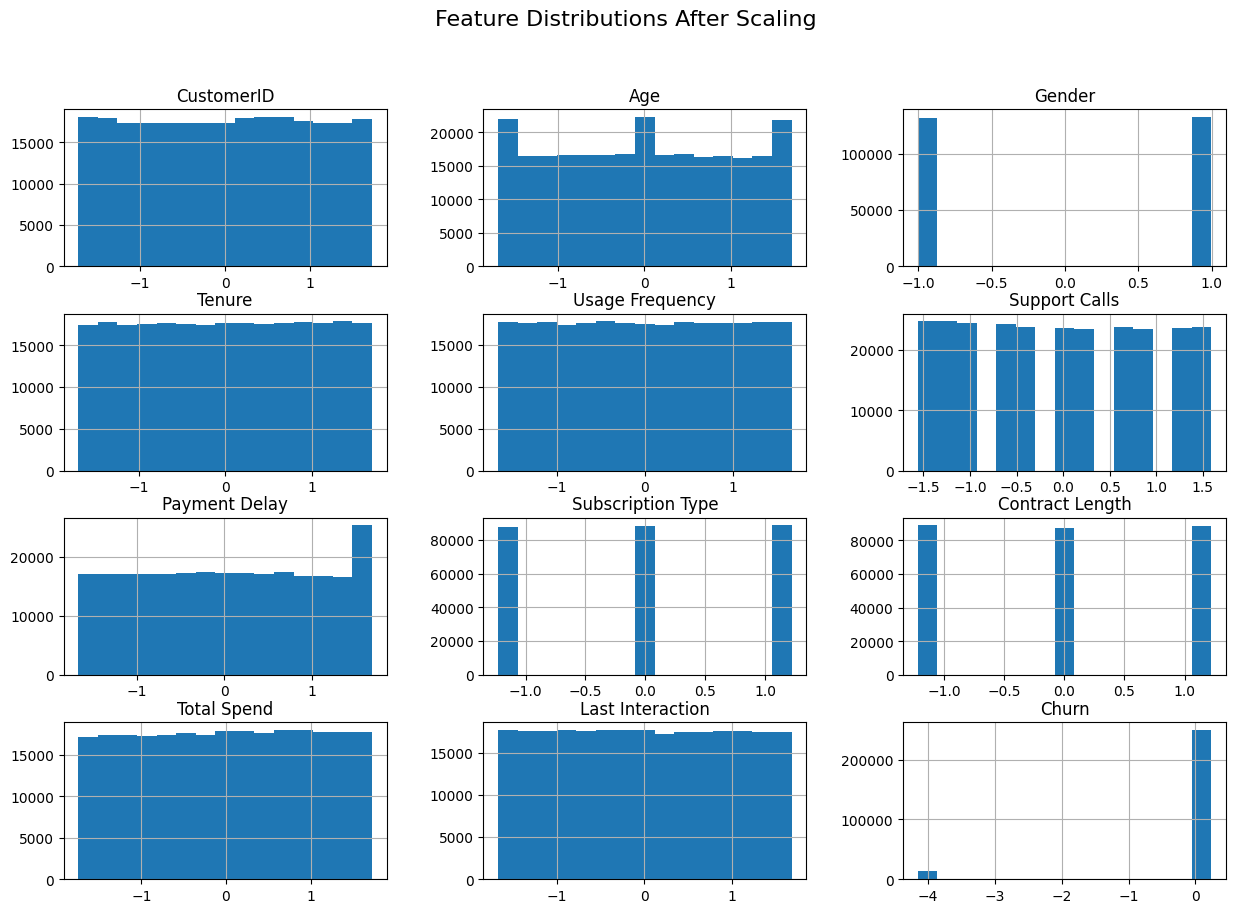

In [202]:
hist = X_train.hist(bins=15, figsize=(15, 10))
plt.suptitle("Feature Distributions After Scaling", fontsize=16)    
plt.show()

In [203]:
y_test.head()

352660    0
352661    0
352662    0
352663    0
352664    0
Name: Churn, dtype: int64

In [204]:
y_test.unique()

array([0])

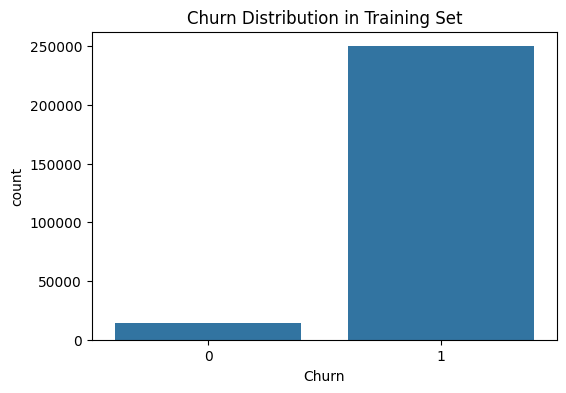

In [205]:
# check label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Churn Distribution in Training Set")
plt.show()

In [206]:
X_train['Churn'].value_counts()

Churn
 0.240749    249999
-4.153698     14490
Name: count, dtype: int64

In [207]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [208]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [209]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
